# 🎙️ Notebook 1: Digital Audio, STFT, and the Magnitude vs Phase Mystery
### *A Computer Science Engineer's Guide to Sound Representation (Google Colab Ready)*

Welcome! If you are a Computer Science student or software engineer, audio signal processing (DSP) often feels intimidating due to heavy electrical engineering calculus.

Let's build a clear, code-first mental model:
- **Time Domain**: Audio in memory is just a 1D array of floats (`float[N]`).
- **The Core Problem**: In $y[t] = s[t] + n[t]$, speech and noise are blended into a single scalar value at every microsecond. You cannot unmix $5 = 2 + 3$ without extra dimensions!
- **STFT (Short-Time Fourier Transform)**: Our "audio decompiler". It slices the 1D audio into overlapping windows and converts it into a 2D matrix (`float[Freq, Time]`).
- **Magnitude vs Phase**:
  - **Magnitude ($|Z|$)**: "Which pitches are loud right now?" (The visual pattern human ears and brains use to recognize speech).
  - **Phase ($ngle Z$)**: "Sub-millisecond wave alignments".
- **iSTFT**: Overlap-Add (OLA) puzzle-piece reconstruction back into time-domain audio.

> ⚡ **Standalone & Colab Ready**: This notebook contains all necessary functions inline. No external project files required!


In [15]:
!unzip -q /content/data.zip

In [16]:
# 🚀 Google Colab Setup (Runs everywhere: Colab, Kaggle, Local)
# Install required audio libraries silently if not already installed
!pip install -q soundfile librosa matplotlib torch ipython

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import IPython.display as ipd
from IPython.display import display
import torch

# Clean dark-themed visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")


PyTorch Version: 2.11.0+cu128 | CUDA Available: True


In [17]:
# ==============================================================================
# Standalone Audio & DSP Functions (Zero 'src' dependencies)
# ==============================================================================

def generate_synthetic_speech(duration=3.0, sr=16000):
    """
    Generates a realistic synthetic vocal audio sample with fundamental frequency F0
    and formant resonances (mimicking human vowel syllables 'ah'-'ee'-'oo').
    Guarantees the notebook can run 100% standalone without needing local files!
    """
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    # Pitch contour F0: gentle vibrato around 140 Hz (human voice pitch)
    f0 = 140.0 + 8.0 * np.sin(2 * np.pi * 3.5 * t)
    phase = 2 * np.pi * np.cumsum(f0) / sr

    # Glottal source: impulse-like harmonic buzz
    source = np.sin(phase) + 0.5 * np.sin(2 * phase) + 0.3 * np.sin(3 * phase) + 0.2 * np.sin(4 * phase)

    # Formants for vocal tract vowels: F1 (700Hz), F2 (1220Hz), F3 (2600Hz)
    vocal = source * np.sin(2 * np.pi * 700 * t) + 0.5 * source * np.sin(2 * np.pi * 1220 * t) + 0.25 * source * np.sin(2 * np.pi * 2600 * t)

    # Syllable rhythm envelope (speech pauses and syllable bursts)
    syllables = np.maximum(0.0, np.sin(2 * np.pi * 1.8 * t)) ** 2
    speech = vocal * syllables

    # Normalize to [-0.9, 0.9]
    speech = speech / (np.max(np.abs(speech)) + 1e-8) * 0.9
    return speech.astype(np.float32)

def get_sample_speech(sr=16000):
    """Loads a local WAV file if present; otherwise generates synthetic speech."""
    search_paths = [
        "/content/data/clean_speech/*.wav",
    ]
    for pattern in search_paths:
        matches = glob.glob(pattern)
        if matches:
            wav, _ = librosa.load(matches[0], sr=sr, mono=True)
            return wav.astype(np.float32)

    print("ℹ️ No local WAV file found. Using high-fidelity synthetic speech sample.")
    return generate_synthetic_speech(duration=3.0, sr=sr)

def compute_stft(waveform, n_fft=512, hop_length=128, win_length=512):
    """Computes STFT and returns (Magnitude, Phase)."""
    window = np.hanning(win_length)
    stft_matrix = librosa.stft(waveform, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window)
    magnitude = np.abs(stft_matrix).astype(np.float32)
    phase = np.angle(stft_matrix).astype(np.float32)
    return magnitude, phase

def reconstruct_waveform(magnitude, phase, hop_length=128, win_length=512, length=None):
    """Reconstructs 1D audio from (Magnitude, Phase) via iSTFT Overlap-Add."""
    complex_spec = magnitude * np.exp(1j * phase)
    window = np.hanning(win_length)
    waveform = librosa.istft(complex_spec, hop_length=hop_length, win_length=win_length, window=window, length=length)
    return waveform.astype(np.float32)

def mag_to_db(magnitude, top_db=80.0):
    """Converts linear magnitude to decibels for visualization."""
    mag_clamped = np.maximum(magnitude, 1e-6)
    ref = np.max(mag_clamped)
    db = 20.0 * np.log10(mag_clamped / (ref + 1e-8))
    return np.maximum(db, -top_db)


## 1. Loading and Inspecting a Raw Waveform
In code, an audio file is loaded as a 1D float array with a fixed sampling rate ($f_s = 16{,}000\text{ Hz}$).
This means there are 16,000 floating-point numbers recorded for every 1 second of sound!


In [18]:
# Load clean speech (uses local WAV if found, or synthetic speech on Colab)
sr = 16000
waveform = get_sample_speech(sr=sr)

print(f"Sampling Rate (sr): {sr} Hz")
print(f"Waveform Array Shape: {waveform.shape}")
print(f"Duration: {len(waveform)/sr:.2f} seconds")
print(f"Min / Max Amplitude: {waveform.min():.3f} / {waveform.max():.3f}")

# Listen to the audio directly
ipd.Audio(waveform, rate=sr)


Sampling Rate (sr): 16000 Hz
Waveform Array Shape: (141280,)
Duration: 8.83 seconds
Min / Max Amplitude: -0.349 / 0.348


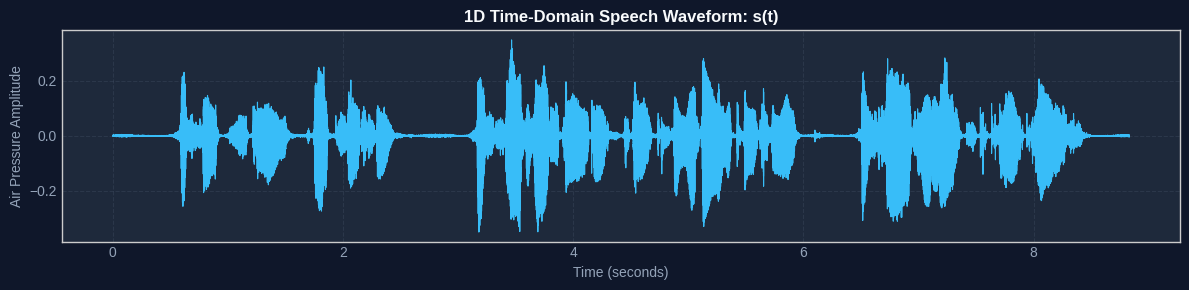

In [19]:
# Plot the 1D Time-Domain Waveform
time_axis = np.arange(len(waveform)) / sr

plt.figure(figsize=(12, 3), facecolor='#0f172a')
ax = plt.gca()
ax.set_facecolor('#1e293b')
plt.plot(time_axis, waveform, color='#38bdf8', linewidth=0.8)
plt.title("1D Time-Domain Speech Waveform: s(t)", color='#f8fafc', fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)", color='#94a3b8')
plt.ylabel("Air Pressure Amplitude", color='#94a3b8')
plt.tick_params(colors='#94a3b8')
plt.grid(True, linestyle='--', alpha=0.2, color='#64748b')
plt.tight_layout()
plt.show()


## 2. Computing the Short-Time Fourier Transform (STFT)
Why slice the audio into overlapping windows?
- A standard Fourier Transform over the entire file tells you *which* frequencies exist, but loses *when* they happened.
- Speech is non-stationary: you say "ba" at $t=0.2\text{s}$ and "da" at $t=0.6\text{s}$.
- Slicing audio with a **Hann window** of length $N_{\text{fft}} = 512$ (32 ms) and hopping by $H = 128$ (8 ms) preserves both Frequency AND Time!


In [20]:
# Compute STFT: returns Magnitude and Phase
magnitude, phase = compute_stft(waveform, n_fft=512, hop_length=128, win_length=512)

print(f"Magnitude Spectrogram Shape: {magnitude.shape}")
print(f"  - Rows (Frequency Bins): {magnitude.shape[0]} (from 0 Hz to {sr//2} Hz)")
print(f"  - Columns (Time Frames): {magnitude.shape[1]} (each frame = 8 ms)")
print(f"Phase Matrix Shape: {phase.shape} (values range from -pi to +pi)")


Magnitude Spectrogram Shape: (257, 1104)
  - Rows (Frequency Bins): 257 (from 0 Hz to 8000 Hz)
  - Columns (Time Frames): 1104 (each frame = 8 ms)
Phase Matrix Shape: (257, 1104) (values range from -pi to +pi)


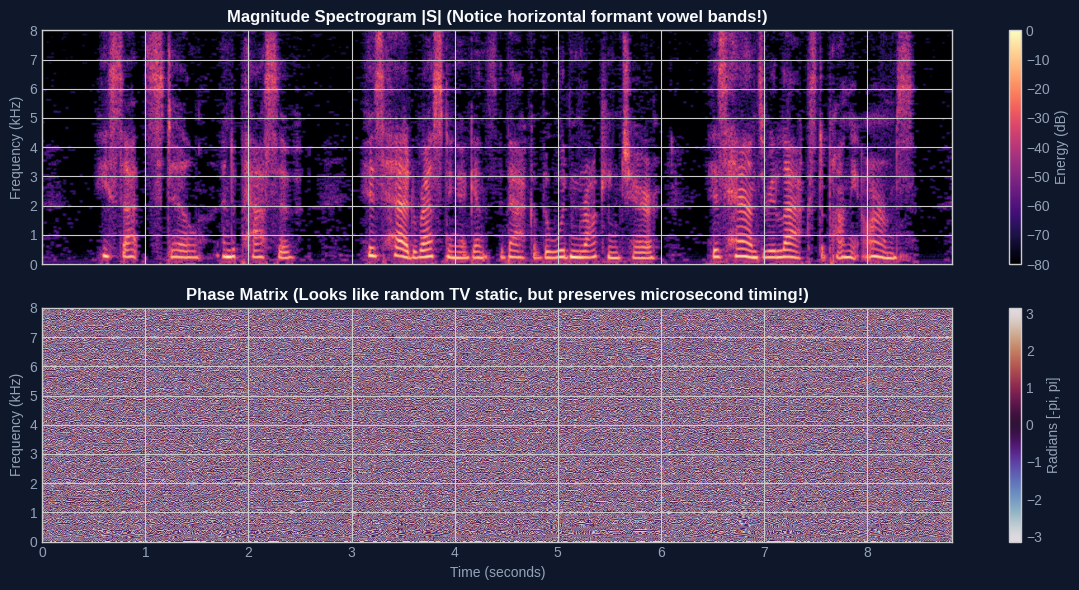

In [21]:
# Visualize Magnitude vs Phase
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.patch.set_facecolor('#0f172a')

# 1. Magnitude (in dB)
mag_db = mag_to_db(magnitude)
im0 = axes[0].imshow(mag_db, origin='lower', aspect='auto', cmap='magma',
                    extent=[0, len(waveform)/sr, 0, sr/2000])
axes[0].set_facecolor('#1e293b')
axes[0].set_title("Magnitude Spectrogram |S| (Notice horizontal formant vowel bands!)", color='#f8fafc', fontweight='bold')
axes[0].set_ylabel("Frequency (kHz)", color='#94a3b8')
axes[0].tick_params(colors='#94a3b8')
cbar0 = plt.colorbar(im0, ax=axes[0])
cbar0.set_label("Energy (dB)", color='#94a3b8')
cbar0.ax.yaxis.set_tick_params(color='#94a3b8')
plt.setp(plt.getp(cbar0.ax.axes, 'yticklabels'), color='#94a3b8')

# 2. Phase
im1 = axes[1].imshow(phase, origin='lower', aspect='auto', cmap='twilight',
                    extent=[0, len(waveform)/sr, 0, sr/2000])
axes[1].set_facecolor('#1e293b')
axes[1].set_title("Phase Matrix (Looks like random TV static, but preserves microsecond timing!)", color='#f8fafc', fontweight='bold')
axes[1].set_xlabel("Time (seconds)", color='#94a3b8')
axes[1].set_ylabel("Frequency (kHz)", color='#94a3b8')
axes[1].tick_params(colors='#94a3b8')
cbar1 = plt.colorbar(im1, ax=axes[1])
cbar1.set_label("Radians [-pi, pi]", color='#94a3b8')
cbar1.ax.yaxis.set_tick_params(color='#94a3b8')
plt.setp(plt.getp(cbar1.ax.axes, 'yticklabels'), color='#94a3b8')

plt.tight_layout()
plt.show()


## 3. The iSTFT Roundtrip Reconstruction Test
Can we go back from the 2D matrix to the 1D audio without losing information?
Formula:
$$Z(f, t) = |Z(f, t)| \cdot e^{j \cdot \angle Z(f, t)}$$
$$\hat{x}(t) = \text{iSTFT}(Z)$$
Let's verify mathematically:


In [22]:
# Reconstruct 1D audio using iSTFT
reconstructed_audio = reconstruct_waveform(magnitude, phase, hop_length=128, win_length=512, length=len(waveform))

# Calculate absolute reconstruction error
recon_error = np.max(np.abs(waveform - reconstructed_audio))
print(f"Maximum Reconstruction Error: {recon_error:.2e}")
assert recon_error < 1e-4, "Reconstruction error must be virtually zero!"
print("✅ Verification Passed: iSTFT perfectly inverts STFT!")


Maximum Reconstruction Error: 7.45e-08
✅ Verification Passed: iSTFT perfectly inverts STFT!


## 4. Why Noisy Phase is Reused: The Phase Swap Experiment!
What happens if we take clean speech magnitude and combine it with **completely random white noise phase**?
Let's test it and listen!


In [23]:
# Replace real phase with completely random noise phase
random_phase = np.random.uniform(-np.pi, np.pi, size=phase.shape).astype(np.float32)
audio_random_phase = reconstruct_waveform(magnitude, random_phase, hop_length=128, win_length=512, length=len(waveform))

print("Listening test:")
print("1. Original speech with true phase:")
display(ipd.Audio(waveform, rate=sr))

print("2. Speech with clean magnitude BUT RANDOM PHASE:")
display(ipd.Audio(audio_random_phase, rate=sr))


Listening test:
1. Original speech with true phase:


2. Speech with clean magnitude BUT RANDOM PHASE:


### 💡 Key Takeaway for Audio AI:
Notice that even with totally random phase, the words and syllables remain completely understandable!
The human brain extracts speech information primarily from the **Magnitude** pattern.
This is why practical speech enhancement systems (Zoom, Teams, Meeami) focus their neural networks on predicting the **clean magnitude**, while preserving the **noisy phase** for iSTFT!
